In [1]:
import pandas as pd

df= pd.read_csv("ai_student_impact_dataset.csv")

info=df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

ossevare corr votazione, incremento, skill retention e burnout
Major_Category -> più colonne?
Year_of_Study -> diventa int 
Primary_Use_Case -> più colonne?
Prompt_Engineering_Skill -> int
Institutional_Policy -> int


In [2]:
df["GPA_increment"] = df["Post_Semester_GPA"]- df["Pre_Semester_GPA"]

In [3]:
df.value_counts(df["Burnout_Risk_Level"])
trad={"Low":1,"Medium":2,"High":3}
df["Burnout_Risk_Level"]=df["Burnout_Risk_Level"].map(trad)

In [4]:
df[["Burnout_Risk_Level","GPA_increment","Post_Semester_GPA","Skill_Retention_Score"]].corr()

,Burnout_Risk_Level,GPA_increment,Post_Semester_GPA,Skill_Retention_Score
Burnout_Risk_Level,1.000000,-0.006818,-0.095543,-0.058140
GPA_increment,-0.006818,1.000000,0.277146,0.195833
Post_Semester_GPA,-0.095543,0.277146,1.000000,0.169616
Skill_Retention_Score,-0.058140,0.195833,0.169616,1.000000


togliamo ora il target e info su Burnout e Skill Retention

In [5]:
y= df["GPA_increment"].copy()
df.drop(columns=["Burnout_Risk_Level","Skill_Retention_Score"], inplace=True)

In [6]:
df.drop(columns="Student_ID",inplace=True)

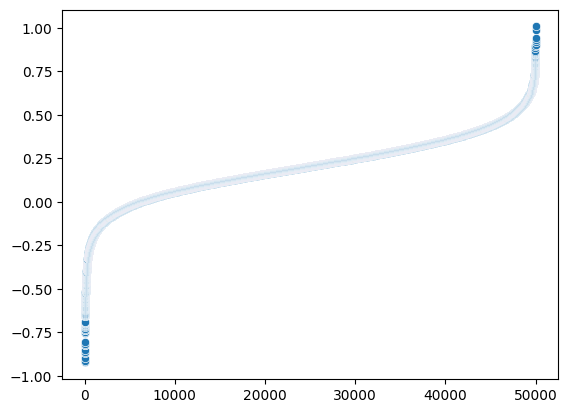

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

x=[]
y=[]

for i, incr in enumerate(df["GPA_increment"].sort_values()):
    x.append(i)
    y.append(incr)


sns.scatterplot(x=x,y=y)
plt.show()


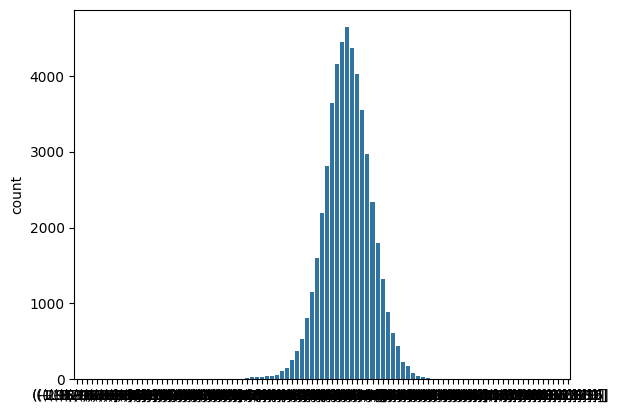

In [8]:

gruppi = pd.cut(y, np.linspace(-2,2,100))

sns.countplot(x=gruppi)
plt.show()


In [9]:
df.value_counts(df["Major_Category"])

Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64

fare modelli diversi per percorsi diversi?

In [10]:
trad={
"Junior": 3 ,
"Freshman" : 1,
"Senior"  : 4, 
"Sophomore"  : 2,
"Graduate" : 5,
}

df["Year_of_Study"]=df["Year_of_Study"].map(trad)

print(df["Year_of_Study"].unique())

[4 3 1 2 5]


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Major_Category              50000 non-null  str    
 1   Year_of_Study               50000 non-null  int64  
 2   Pre_Semester_GPA            50000 non-null  float64
 3   Weekly_GenAI_Hours          50000 non-null  float64
 4   Primary_Use_Case            50000 non-null  str    
 5   Prompt_Engineering_Skill    50000 non-null  str    
 6   Tool_Diversity              50000 non-null  int64  
 7   Paid_Subscription           50000 non-null  bool   
 8   Traditional_Study_Hours     50000 non-null  float64
 9   Perceived_AI_Dependency     50000 non-null  int64  
 10  Institutional_Policy        50000 non-null  str    
 11  Anxiety_Level_During_Exams  50000 non-null  int64  
 12  Post_Semester_GPA           50000 non-null  float64
 13  GPA_increment               50000 non-null

In [12]:
for use in df["Primary_Use_Case"].unique():
    df["is_"+use]= df["Primary_Use_Case"]==use

df.drop(columns="Primary_Use_Case",inplace=True)

In [13]:
df.value_counts(df["Prompt_Engineering_Skill"])

Prompt_Engineering_Skill
Beginner        18495
Intermediate    17696
Advanced        13809
Name: count, dtype: int64

In [14]:
trad={
"Beginner": 1 ,
"Intermediate" : 2,
"Advanced"  : 3, 
}

df["Prompt_Engineering_Skill"]=df["Prompt_Engineering_Skill"].map(trad)

print(df["Prompt_Engineering_Skill"].unique())

[1 3 2]


In [15]:

df.value_counts(df["Institutional_Policy"])

Institutional_Policy
Allowed_With_Citation    25224
Actively_Encouraged      14988
Strict_Ban                9788
Name: count, dtype: int64

In [16]:
for corso in df["Institutional_Policy"].unique():
    df["is_"+corso]= df["Institutional_Policy"]==corso

df.drop(columns="Institutional_Policy",inplace=True)

primo approccio mantenere categorie tutte assieme nello stesso dataset ma in colonne diverse e vediamo (poi dopo proviamo a dividere dataset per fare 5 modelli diversi)

In [17]:
df_by_category = df.copy() #salvo una copia del dataset per poi usarlo dopo per creare modelli separati

In [18]:
for corso in df["Major_Category"].unique():
    df["major_is_"+corso]= df["Major_Category"]==corso

df.drop(columns="Major_Category",inplace=True)

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

df.drop(columns="GPA_increment",inplace=True,errors=True)
# X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2, random_state=42)

modello baseline

In [20]:
from xgboost import XGBRegressor

# rf_model = XGBRegressor(
#     n_estimators=100,
#     random_state=42
# )


# rf_model.fit(X_train, y_train) 

In [21]:
# predictions = rf_model.predict(X_test)

# print(mean_absolute_error(y_test, predictions))

# print(r2_score(y_test, predictions))

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year_of_Study                 50000 non-null  int64  
 1   Pre_Semester_GPA              50000 non-null  float64
 2   Weekly_GenAI_Hours            50000 non-null  float64
 3   Prompt_Engineering_Skill      50000 non-null  int64  
 4   Tool_Diversity                50000 non-null  int64  
 5   Paid_Subscription             50000 non-null  bool   
 6   Traditional_Study_Hours       50000 non-null  float64
 7   Perceived_AI_Dependency       50000 non-null  int64  
 8   Anxiety_Level_During_Exams    50000 non-null  int64  
 9   Post_Semester_GPA             50000 non-null  float64
 10  is_Copywriting/Drafting       50000 non-null  bool   
 11  is_Ideation                   50000 non-null  bool   
 12  is_Summarizing_Reading        50000 non-null  bool   
 13  is_Debugging

In [23]:
# un dataframe per ogni categoria
df_dict={
    k:df_by_category[df_by_category["Major_Category"] == k]  for k in df_by_category["Major_Category"].unique()
}


In [24]:
for d in df_dict.values():
    d.drop(columns=["Major_Category"], inplace=True)
    d.drop(columns=["GPA_increment"], inplace=True)
d.info()

df_dict["Tutti i major"]=df


<class 'pandas.DataFrame'>
Index: 5933 entries, 7 to 49999
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year_of_Study                 5933 non-null   int64  
 1   Pre_Semester_GPA              5933 non-null   float64
 2   Weekly_GenAI_Hours            5933 non-null   float64
 3   Prompt_Engineering_Skill      5933 non-null   int64  
 4   Tool_Diversity                5933 non-null   int64  
 5   Paid_Subscription             5933 non-null   bool   
 6   Traditional_Study_Hours       5933 non-null   float64
 7   Perceived_AI_Dependency       5933 non-null   int64  
 8   Anxiety_Level_During_Exams    5933 non-null   int64  
 9   Post_Semester_GPA             5933 non-null   float64
 10  is_Copywriting/Drafting       5933 non-null   bool   
 11  is_Ideation                   5933 non-null   bool   
 12  is_Summarizing_Reading        5933 non-null   bool   
 13  is_Debugging/Troub

In [25]:
def make_primary_use_case_dict(X,y):
    dictionary={}
    
    for use in X["Primary_Use_Case"].unique():
        # estra in base a use case i solo target corrispondenti
        only_use_target=y[X["Primary_Use_Case"]==use]
        #calcola media poi lo mette nel dizionario
        dictionary[use]=np.mean(only_use_target)

    return dictionary


In [26]:
model_params_major_dict={}

import optuna

def objective(trial):

    data= df_dict[corso]
    y=data["Post_Semester_GPA"]
    X=data.drop(columns='Post_Semester_GPA')

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'mae',
        'tree_method': 'hist',
        'enable_categorical':True,
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 0,
        'bootstrap_type': "Bayesian",
        
       
        'n_estimators': trial.suggest_int('n_estimators', 50, 250),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3,18),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True)
    }

    if params["bootstrap_type"] == "Bayesian":
        params["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0, 10)
    elif params["bootstrap_type"] == "Bernoulli":
        params["subsample"] = trial.suggest_float("subsample", 0.1, 1)

    model = XGBRegressor(**params)
    #FEATURE ENG irrilevante 
    # use_case_dict=make_primary_use_case_dict(X_train,y_train)

    # X_train["Primary_Use_Case"]=X_train["Primary_Use_Case"].map(use_case_dict)
    # X_test["Primary_Use_Case"]=X_test["Primary_Use_Case"].map(use_case_dict)
    

    model.fit(X_train, y_train,verbose=1)

    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    return mae


c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
best_model_major_dict={}
import seaborn as sns
for corso in df_dict.keys():
    
    print(f"major {corso}")
    c=corso

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=100, timeout=600)

    print("Number of finished trials: {}".format(len(study.trials)))

    print("Best trial:")
    trial = study.best_trial

    print("  Value: {}".format(trial.value))

    print("  Params: ")
    for key, value in trial.params.items():
        print("    {}: {}".format(key, value))
    
    optimal_params = study.best_trial.params
    model_params_major_dict[corso]=optimal_params
    model=XGBRegressor(**optimal_params)
    data= df_dict[corso]
    y=data["Post_Semester_GPA"]
    X=data.drop(columns='Post_Semester_GPA')

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # use_case_dict=make_primary_use_case_dict(X_train,y_train)

    # X_train["Primary_Use_Case"]=X_train["Primary_Use_Case"].map(use_case_dict)
    # X_test["Primary_Use_Case"]=X_test["Primary_Use_Case"].map(use_case_dict)
    
    model.fit(X_train,y_train)
    preds = model.predict(X_test)

    print("business mae:", mean_absolute_error(y_test, preds))
    print("business r2:", r2_score(y_test, preds))
    best_model_major_dict[corso]=model    


[I 2026-06-08 10:22:55,468] A new study created in memory with name: no-name-40db28f6-3991-4fdd-9d2a-848a3691c006


major Humanities


[I 2026-06-08 10:22:56,230] Trial 0 finished with value: 0.3004558436358911 and parameters: {'n_estimators': 245, 'learning_rate': 0.0020132816123897028, 'max_depth': 14, 'subsample': 0.6513964317181556, 'colsample_bytree': 0.8082293137969434, 'reg_alpha': 0.09634359210234017, 'bagging_temperature': 9.95058450642063}. Best is trial 0 with value: 0.3004558436358911.
[I 2026-06-08 10:22:56,342] Trial 1 finished with value: 0.19765938336924352 and parameters: {'n_estimators': 191, 'learning_rate': 0.00541410335161234, 'max_depth': 7, 'subsample': 0.9276993965610719, 'colsample_bytree': 0.9572054231855674, 'reg_alpha': 0.0010816226393226482, 'bagging_temperature': 5.261212592075467}. Best is trial 1 with value: 0.19765938336924352.
[I 2026-06-08 10:22:56,691] Trial 2 finished with value: 0.13209935628061834 and parameters: {'n_estimators': 122, 'learning_rate': 0.02114903722878843, 'max_depth': 12, 'subsample': 0.7615227499182724, 'colsample_bytree': 0.9493075461013032, 'reg_alpha': 0.0213

Number of finished trials: 100
Best trial:
  Value: 0.11628467251432723
  Params: 
    n_estimators: 160
    learning_rate: 0.11591546785065267
    max_depth: 12
    subsample: 0.7882300620583617
    colsample_bytree: 0.7341561477105363
    reg_alpha: 4.824937293580494
    bagging_temperature: 4.549143486154798
business mae: 0.11698171144392921
business r2: 0.9125670892657942
major Medical


[I 2026-06-08 10:23:09,837] Trial 1 finished with value: 0.13363514104595892 and parameters: {'n_estimators': 245, 'learning_rate': 0.1643387200667617, 'max_depth': 11, 'subsample': 0.7942253753932083, 'colsample_bytree': 0.6188800509738622, 'reg_alpha': 0.003530652872379435, 'bagging_temperature': 8.327369335736464}. Best is trial 0 with value: 0.11919533171992244.
[I 2026-06-08 10:23:09,899] Trial 2 finished with value: 0.2601456904249427 and parameters: {'n_estimators': 139, 'learning_rate': 0.006204668754874621, 'max_depth': 11, 'subsample': 0.6291142585215143, 'colsample_bytree': 0.7366578179156313, 'reg_alpha': 8.994070485494083, 'bagging_temperature': 7.295681220645674}. Best is trial 0 with value: 0.11919533171992244.
[I 2026-06-08 10:23:10,371] Trial 3 finished with value: 0.14392008634261147 and parameters: {'n_estimators': 113, 'learning_rate': 0.02982661363063864, 'max_depth': 14, 'subsample': 0.9699436760272018, 'colsample_bytree': 0.9232138063707893, 'reg_alpha': 0.005955

...

Number of finished trials: 100
Best trial:
  Value: 0.11646768141806048
  Params: 
    n_estimators: 213
    learning_rate: 0.03802797877474663
    max_depth: 5
    subsample: 0.7377909413854234
    colsample_bytree: 0.9995050305374048
    reg_alpha: 0.01744220728166631
    bagging_temperature: 9.925658581373463
business mae: 0.11647940676462444
business r2: 0.9069675333872435
major Arts


[I 2026-06-08 10:23:50,738] Trial 0 finished with value: 0.1758796163332392 and parameters: {'n_estimators': 170, 'learning_rate': 0.020648951055754813, 'max_depth': 17, 'subsample': 0.9230413857929364, 'colsample_bytree': 0.6143776289735116, 'reg_alpha': 0.024457786439799598, 'bagging_temperature': 8.890280806774287}. Best is trial 0 with value: 0.1758796163332392.
[I 2026-06-08 10:23:50,927] Trial 1 finished with value: 0.12625016719107882 and parameters: {'n_estimators': 205, 'learning_rate': 0.16093644064076534, 'max_depth': 12, 'subsample': 0.7278013131375793, 'colsample_bytree': 0.9936190026416408, 'reg_alpha': 0.8089656947634883, 'bagging_temperature': 1.8599902204210705}. Best is trial 1 with value: 0.12625016719107882.
[I 2026-06-08 10:23:51,133] Trial 2 finished with value: 0.13155768037826548 and parameters: {'n_estimators': 231, 'learning_rate': 0.10563182906012207, 'max_depth': 9, 'subsample': 0.7862861337328602, 'colsample_bytree': 0.7051903700002639, 'reg_alpha': 0.00284

Number of finished trials: 100
Best trial:
  Value: 0.11822576379655486
  Params: 
    n_estimators: 102
    learning_rate: 0.17982375169040368
    max_depth: 3
    subsample: 0.944264386469354
    colsample_bytree: 0.9882299471333035
    reg_alpha: 1.5063227379619348
    bagging_temperature: 7.306822953308763
business mae: 0.11833734265193281
business r2: 0.9140625700096286
major Tutti i major


[I 2026-06-08 10:23:59,684] Trial 1 finished with value: 0.18144685705680846 and parameters: {'n_estimators': 130, 'learning_rate': 0.008439756608614311, 'max_depth': 8, 'subsample': 0.6220616101265877, 'colsample_bytree': 0.9640325533134778, 'reg_alpha': 0.0023024589560415626, 'bagging_temperature': 0.9592488708560132}. Best is trial 0 with value: 0.11436700277423859.
[I 2026-06-08 10:24:00,492] Trial 2 finished with value: 0.1171644339653015 and parameters: {'n_estimators': 117, 'learning_rate': 0.07196876066975501, 'max_depth': 16, 'subsample': 0.6726296687729264, 'colsample_bytree': 0.7509453529885736, 'reg_alpha': 0.6827019050773347, 'bagging_temperature': 4.343320533827944}. Best is trial 0 with value: 0.11436700277423859.
[I 2026-06-08 10:24:01,609] Trial 3 finished with value: 0.29436420757102966 and parameters: {'n_estimators': 86, 'learning_rate': 0.0058812797911353635, 'max_depth': 15, 'subsample': 0.7899053806512507, 'colsample_bytree': 0.7045486432367865, 'reg_alpha': 0.15

Number of finished trials: 100
Best trial:
  Value: 0.11200613345499039
  Params: 
    n_estimators: 131
    learning_rate: 0.0935688867609461
    max_depth: 5
    subsample: 0.682489371601602
    colsample_bytree: 0.9410252625273182
    reg_alpha: 0.3794011739108791
    bagging_temperature: 8.97133778978263
business mae: 0.11242641072187423
business r2: 0.9156272521975775


In [28]:
df_dict['Tutti i major'].info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year_of_Study                 50000 non-null  int64  
 1   Pre_Semester_GPA              50000 non-null  float64
 2   Weekly_GenAI_Hours            50000 non-null  float64
 3   Prompt_Engineering_Skill      50000 non-null  int64  
 4   Tool_Diversity                50000 non-null  int64  
 5   Paid_Subscription             50000 non-null  bool   
 6   Traditional_Study_Hours       50000 non-null  float64
 7   Perceived_AI_Dependency       50000 non-null  int64  
 8   Anxiety_Level_During_Exams    50000 non-null  int64  
 9   Post_Semester_GPA             50000 non-null  float64
 10  is_Copywriting/Drafting       50000 non-null  bool   
 11  is_Ideation                   50000 non-null  bool   
 12  is_Summarizing_Reading        50000 non-null  bool   
 13  is_Debugging

c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:24:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Humanities mae: 0.11698171144392921
Humanities r2: 0.9125670892657942
Medical mae: 0.1157122480891369
Medical r2: 0.9152083881349546


c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:24:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:24:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Business mae: 0.11549562636136629
Business r2: 0.9078578866910831


c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:24:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


STEM mae: 0.11647940676462444
STEM r2: 0.9069675333872435
Arts mae: 0.11833734265193281
Arts r2: 0.9140625700096286


c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:24:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:24:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Tutti i major mae: 0.11242641072187423
Tutti i major r2: 0.9156272521975775


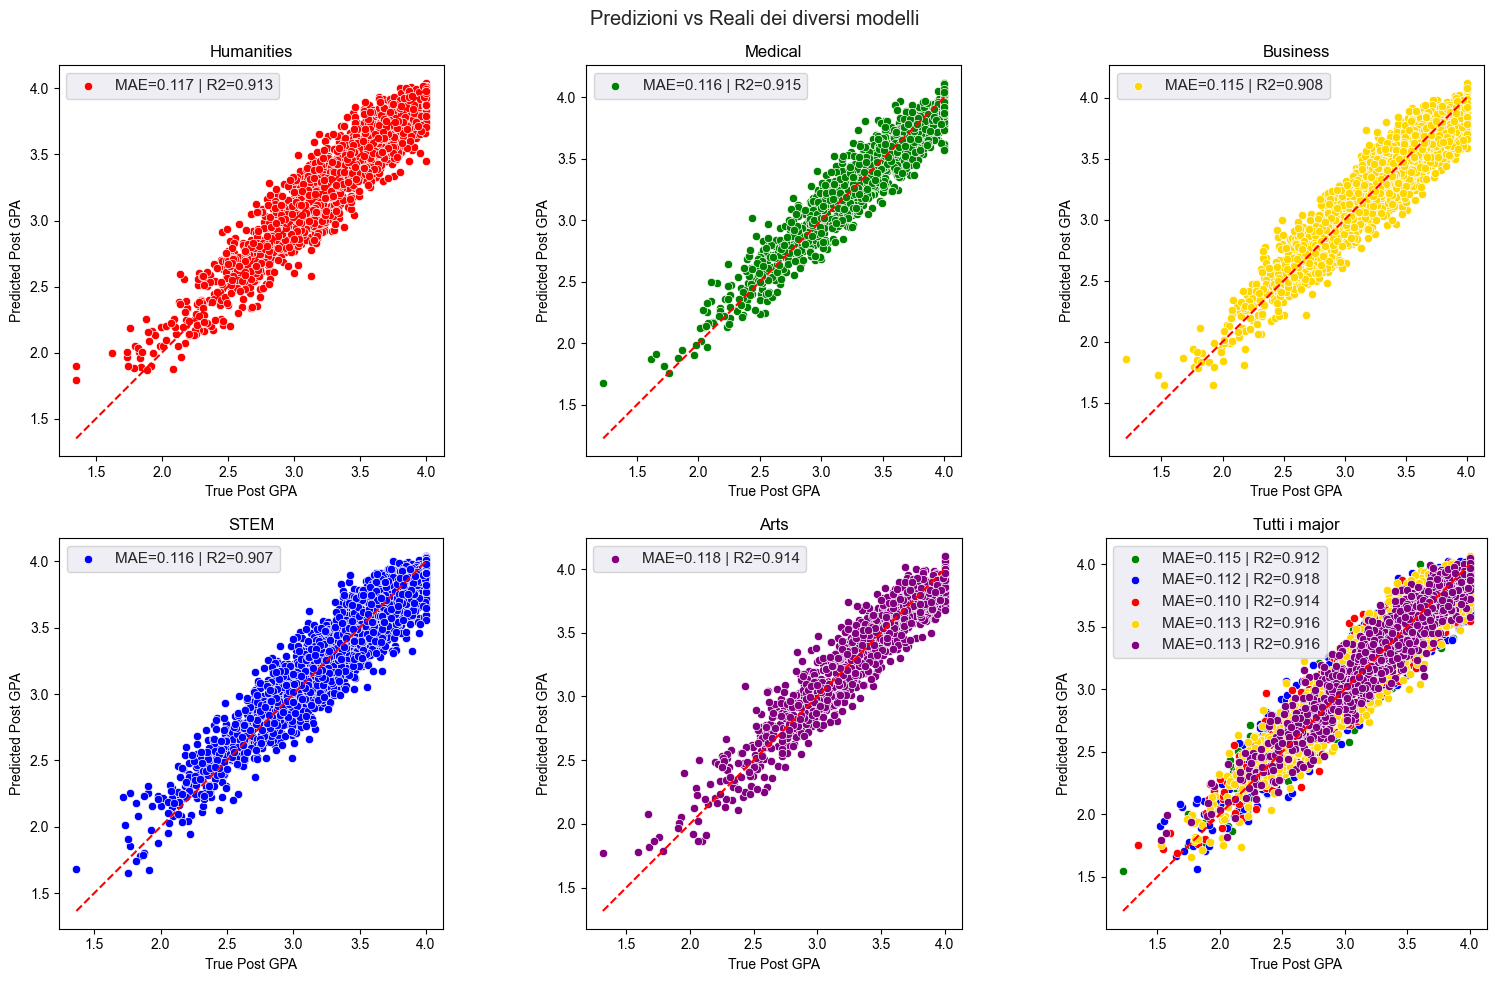

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
sns.set_theme(style='darkgrid')

corso_color = {
    "Medical": "green",
    "STEM": "blue",
    "Humanities": "red",
    "Business": "gold",
    "Arts": "purple"
}

for i, corso in enumerate(df_dict):
    optimal_params = model_params_major_dict[corso]

    model = XGBRegressor(**optimal_params)

    data = df_dict[corso]

    y = data["Post_Semester_GPA"]
    X = data.drop(columns="Post_Semester_GPA")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    # use_case_dict=make_primary_use_case_dict(X_train,y_train)

    # X_train["Primary_Use_Case"]=X_train["Primary_Use_Case"].map(use_case_dict)
    # X_test["Primary_Use_Case"]=X_test["Primary_Use_Case"].map(use_case_dict)

    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"{corso} mae:", mae)
    print(f"{corso} r2:", r2)
    if "Tutti" not in corso:
        sns.scatterplot(
            x=y_test,
            y=preds,
            ax=axes[i],
            c=corso_color[corso],
            label=f"MAE={mae:.3f} | R2={r2:.3f}"
        )
    else:
        real_vs_preds=list(zip(y_test,preds))
    
        for cors in corso_color.keys():
            if "Tutti" in cors:
                continue
            mask= X_test["major_is_"+cors]==True
            tmp=[[e[0],e[1]] for e,m in zip(real_vs_preds,mask) if m]
            
            tmp_real=[e[0] for e in tmp ]
            tmp_pred=[e[1] for e in tmp ]

            mae = mean_absolute_error(tmp_real, tmp_pred)
            r2 = r2_score(tmp_real, tmp_pred)

            sns.scatterplot(
            x=tmp_real,
            y=tmp_pred,
            ax=axes[i],
            c=corso_color[cors],
            label=f"MAE={mae:.3f} | R2={r2:.3f}"
        )


        

    axes[i].set_title(corso)
    axes[i].set_xlabel("True Post GPA")
    axes[i].set_ylabel("Predicted Post GPA")
    axes[i].set_aspect('equal', adjustable='box')
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],c='red', linestyle='--',)

    

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
fig.suptitle("Predizioni vs Reali dei diversi modelli")
plt.tight_layout()
plt.show()